# Module 4 Lab 1: Describe and Correlate

**CS 82A - Introduction to Data Science**

**Ramisha Tasfia**

**GitHub:** https://github.com/ramishatasfia5156-commits/cs82a-coursework/blob/main/module4/module4_lab.ipynb

## Load the Clean Data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import statistics

df = pd.read_csv('sales_clean.csv')
print('Shape as loaded:', df.shape)

Shape as loaded: (292, 6)


In [2]:
# The sales_clean.csv in my repo was pushed before the Module 3 Lab 1 step that removed
# the 3 negative-quantity orders (1140, 1233, 1025). Applying that same documented step here.
print(df[df['qty'] < 0])
df = df[df['qty'] >= 0]
df['zip'] = df['zip'].astype(str).str.zfill(5)   # zip codes are identifiers, not numbers
print()
print('Shape after removing negative qty:', df.shape)

     order_id        date    product  price  qty    zip
199      1140  2026-04-18     webcam  38.69   -5  98101
255      1233  2026-05-09  desk lamp  22.64   -4  10001
289      1025  2026-04-27   keyboard  47.30   -2   2116

Shape after removing negative qty: (289, 6)


## Center and Spread of Price and Qty

In [3]:
summary = pd.DataFrame({
    'mean':   [df['price'].mean(),   df['qty'].mean()],
    'median': [df['price'].median(), df['qty'].median()],
    'std':    [df['price'].std(),    df['qty'].std()],
}, index=['price', 'qty']).round(2)
summary

,mean,median,std
price,55.72,37.53,72.11
qty,2.98,3.00,1.41


## Which Summary Would I Report?

For price I would report the median ($37.53), instead of the mean ($55.72). The mean is about $18 higher than the median because of a small number of very expensive monitors (up to $479), which are pulling it upward. Therefore, the mean describes a price that most individual orders will not reach. The median better represents the price of a typical order in this data set because it is not affected by the high-priced values at the tail.

## Histogram of Price

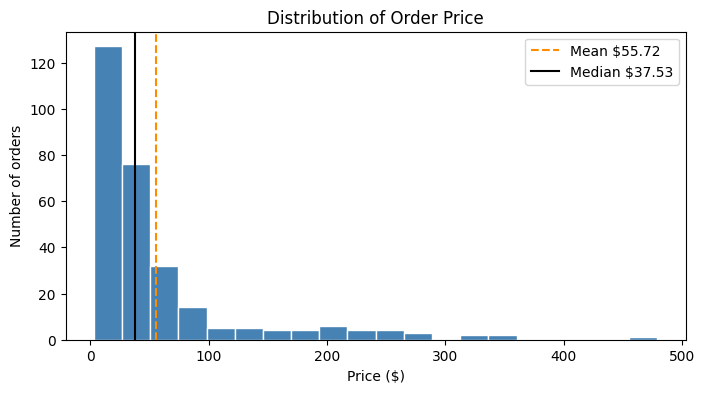

In [4]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(df['price'], bins=20, color='steelblue', edgecolor='white')
ax.axvline(df['price'].mean(), color='darkorange', linestyle='--', label=f"Mean ${df['price'].mean():.2f}")
ax.axvline(df['price'].median(), color='black', linestyle='-', label=f"Median ${df['price'].median():.2f}")
ax.set_title('Distribution of Order Price')
ax.set_xlabel('Price ($)')
ax.set_ylabel('Number of orders')
ax.legend()
plt.show()

**Shape:** right-skewed. Most prices are under $100, with a long tail of expensive items to the right. This agrees with reporting the median.

## Revenue Column

In [5]:
df['revenue'] = df['price'] * df['qty']
df.head()

,order_id,date,product,price,qty,zip,revenue
0,1254,2026-04-06,mug,11.36,4,60614,45.44
1,1057,2026-05-30,charger,14.79,3,30303,44.37
2,1150,2026-05-06,mug,5.50,1,10001,5.50
3,1066,2026-05-30,notebook,37.53,1,98101,37.53
4,1114,2026-04-06,webcam,45.59,4,90405,182.36


## Correlation Matrix

In [6]:
# order_id is a label and zip is now text, so only the measured columns are compared
corr = df[['price', 'qty', 'revenue']].corr(numeric_only=True).round(3)
corr

,price,qty,revenue
price,1.000,-0.040,0.821
qty,-0.040,1.000,0.314
revenue,0.821,0.314,1.000


**Strongest off-diagonal value:** price vs. revenue, r = 0.821 (strong, positive). Qty vs. revenue is r = 0.314 (weak, positive). Price vs. qty is about 0, so customers do not buy fewer units of expensive items.

## Scatter Plots

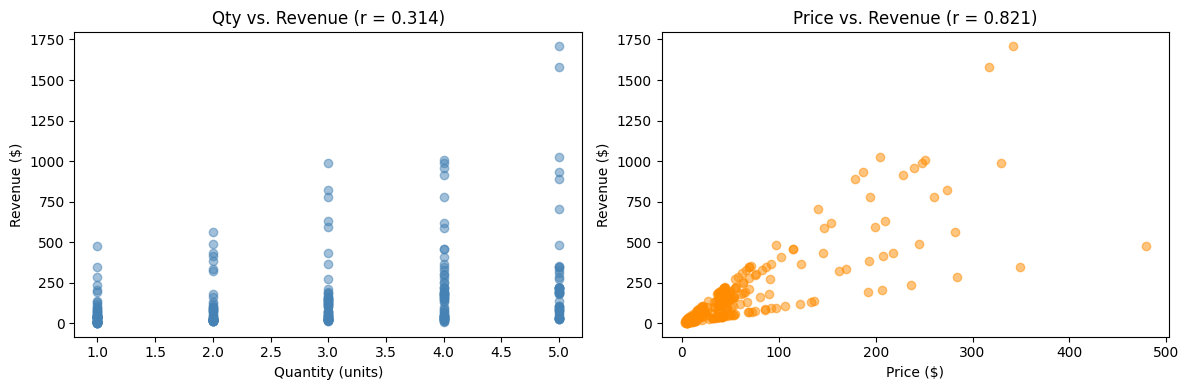

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(df['qty'], df['revenue'], alpha=0.5, color='steelblue')
axes[0].set_title(f"Qty vs. Revenue (r = {corr.loc['qty', 'revenue']})")
axes[0].set_xlabel('Quantity (units)')
axes[0].set_ylabel('Revenue ($)')

axes[1].scatter(df['price'], df['revenue'], alpha=0.5, color='darkorange')
axes[1].set_title(f"Price vs. Revenue (r = {corr.loc['price', 'revenue']})")
axes[1].set_xlabel('Price ($)')
axes[1].set_ylabel('Revenue ($)')

plt.tight_layout()
plt.show()

Both clouds agree with their r values. Qty vs. revenue drifts upward but with a very wide vertical spread at every quantity, which fits a weak r of 0.31. Price vs. revenue rises clearly, fanning out as price grows because quantity varies, which fits a strong r of 0.82.

## The Analyst's Sentence

Revenue is largely driven by an order's price rather than the number of units purchased. There is a strong correlation between price and revenue (r = 0.82), while there is only a weak correlation between quantity and revenue (r = 0.31). However, since revenue is calculated using price, part of this relationship is built into the calculation. Additionally, a small number of expensive monitor orders drive much of the relationship. Therefore, this shows which factor has a stronger relationship with revenue in this particular data set, but it does not mean that increasing prices would necessarily increase revenue.

## By-Hand Check

Data: [2, 4, 4, 6, 9]

**Mean:** (2 + 4 + 4 + 6 + 9) / 5 = 25 / 5 = **5.0**

**Median:** the values are already in order and there are 5 of them, so the median is the 3rd value: **4**

In [8]:
values = [2, 4, 4, 6, 9]
print('Mean:  ', sum(values) / len(values))
print('Median:', statistics.median(values))

Mean:   5.0
Median: 4


## AI Disclosure

**AI Disclosure:** Claude (Anthropic) was used to help explain concepts and draft initial code for this lab. All code was reviewed, retyped, and understood by me. I can explain why the median is the better summary for right-skewed prices, how the histogram shows that skew, how to read the correlation matrix, and why the correlation between price and revenue needs a caution attached.

**Key prompt:** "Help me with Module 4 Lab 1: Describe and Correlate using my sales_clean.csv from Module 3."